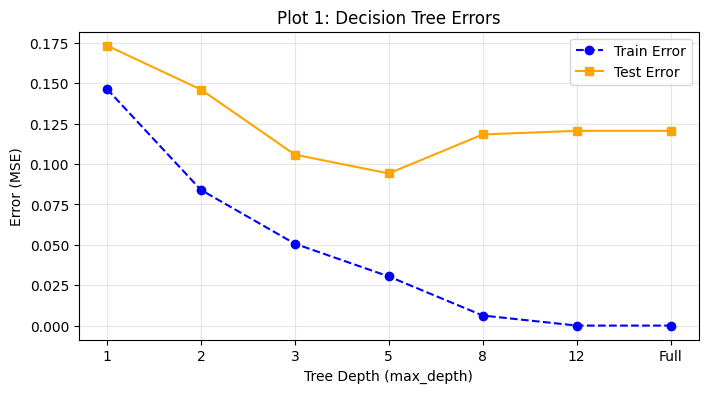

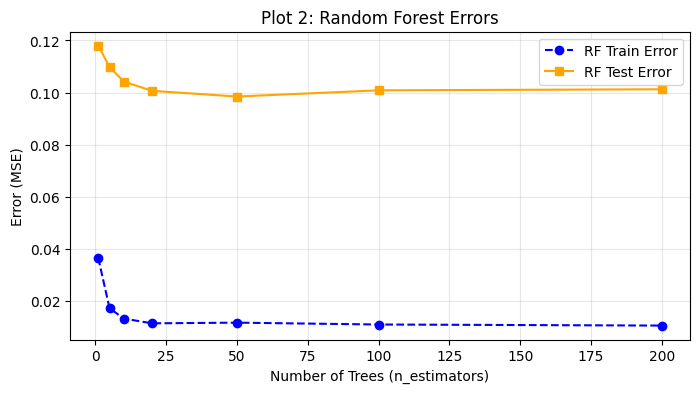

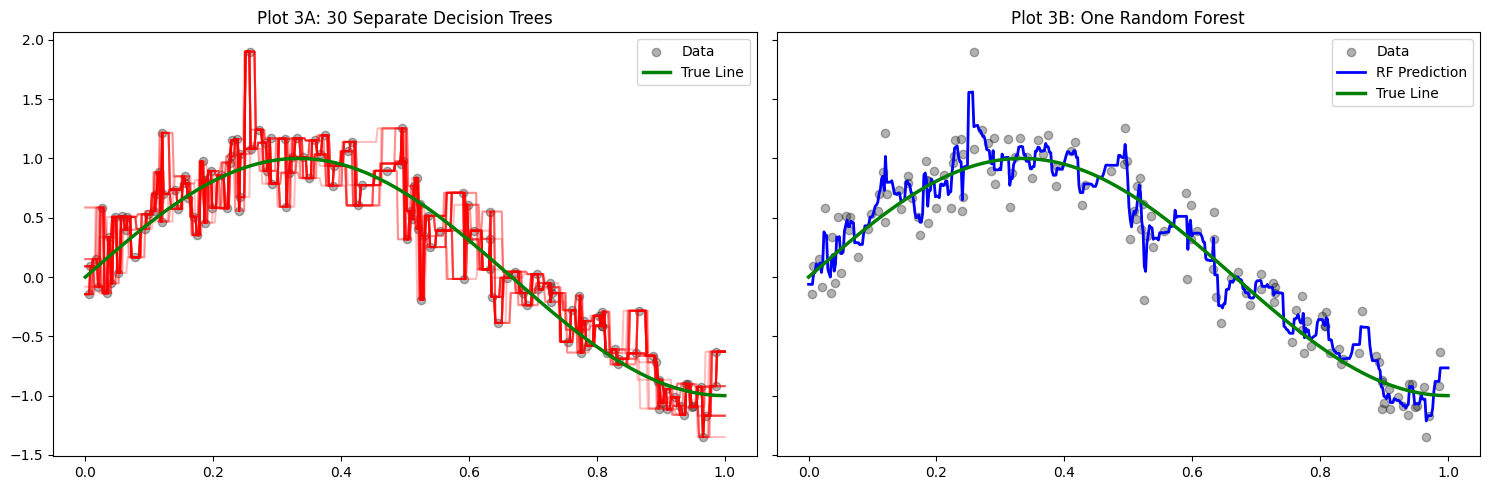

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Dataset banana
np.random.seed(42)

def true_function(x):
    return np.sin(1.5 * np.pi * x)

n_samples = 200
X = np.sort(np.random.rand(n_samples))
y = true_function(X) + np.random.normal(0, 0.25, n_samples)
X = X.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Part A: Decision Tree Model & Plot
dt_fully_grown = DecisionTreeRegressor(max_depth=None, random_state=42)
dt_fully_grown.fit(X_train, y_train)

depths = [1, 2, 3, 5, 8, 12, None]
train_mses = []
test_mses = []

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_mses.append(mean_squared_error(y_train, dt.predict(X_train)))
    test_mses.append(mean_squared_error(y_test, dt.predict(X_test)))

depth_labels = [str(d) if d is not None else 'Full' for d in depths]

plt.figure(figsize=(8, 4))
plt.plot(depth_labels, train_mses, marker='o', label='Train Error', color='blue', linestyle='--')
plt.plot(depth_labels, test_mses, marker='s', label='Test Error', color='orange', linestyle='-')
plt.xlabel('Tree Depth (max_depth)')
plt.ylabel('Error (MSE)')
plt.title('Plot 1: Decision Tree Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Part B: Random Forest Model & Plot
rf_model = RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42)
rf_model.fit(X_train, y_train)

estin_list = [1, 5, 10, 20, 50, 100, 200]
rf_train_mses = []
rf_test_mses = []

for n_est in estin_list:
    rf = RandomForestRegressor(n_estimators=n_est, max_depth=None, random_state=42)
    rf.fit(X_train, y_train)
    rf_train_mses.append(mean_squared_error(y_train, rf.predict(X_train)))
    rf_test_mses.append(mean_squared_error(y_test, rf.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(estin_list, rf_train_mses, marker='o', label='RF Train Error', color='blue', linestyle='--')
plt.plot(estin_list, rf_test_mses, marker='s', label='RF Test Error', color='orange', linestyle='-')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Error (MSE)')
plt.title('Plot 2: Random Forest Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Part C: Bias-Variance Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
x_grid = np.linspace(0, 1, 500).reshape(-1, 1)

# 30 alag-alag trees ka plot
axes[0].scatter(X_train, y_train, color='black', alpha=0.3, label='Data')
for i in range(30):
    idx = np.random.choice(len(X_train), size=len(X_train), replace=True)
    tree = DecisionTreeRegressor(max_depth=None)
    tree.fit(X_train[idx], y_train[idx])
    axes[0].plot(x_grid, tree.predict(x_grid), color='red', alpha=0.25)
axes[0].plot(x_grid, true_function(x_grid), color='green', linewidth=2.5, label='True Line')
axes[0].set_title('Plot 3A: 30 Separate Decision Trees')
axes[0].legend() # Changed from set_legend() to legend()

# Ek single Random Forest ka plot
axes[1].scatter(X_train, y_train, color='black', alpha=0.3, label='Data')
axes[1].plot(x_grid, rf_model.predict(x_grid), color='blue', linewidth=2, label='RF Prediction')
axes[1].plot(x_grid, true_function(x_grid), color='green', linewidth=2.5, label='True Line')
axes[1].set_title('Plot 3B: One Random Forest')
axes[1].legend() # Changed from set_legend() to legend()

plt.tight_layout()
plt.show()